<a href="https://colab.research.google.com/github/hafnailmy-bip/pertemuan4/blob/main/PCD_Tugas_Enhancement_Citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload 3 citra:
1. Underexposed (gelap)
2. Overexposed (terang)
3. Iluminasi tidak merata


Saving Foto Model Warna Normal.jpeg to Foto Model Warna Normal.jpeg
Saving Foto Model Warna Redup.jpeg to Foto Model Warna Redup.jpeg
Saving Foto Model Warna Terang.jpeg to Foto Model Warna Terang.jpeg

Processing: Foto Model Warna Normal.jpeg


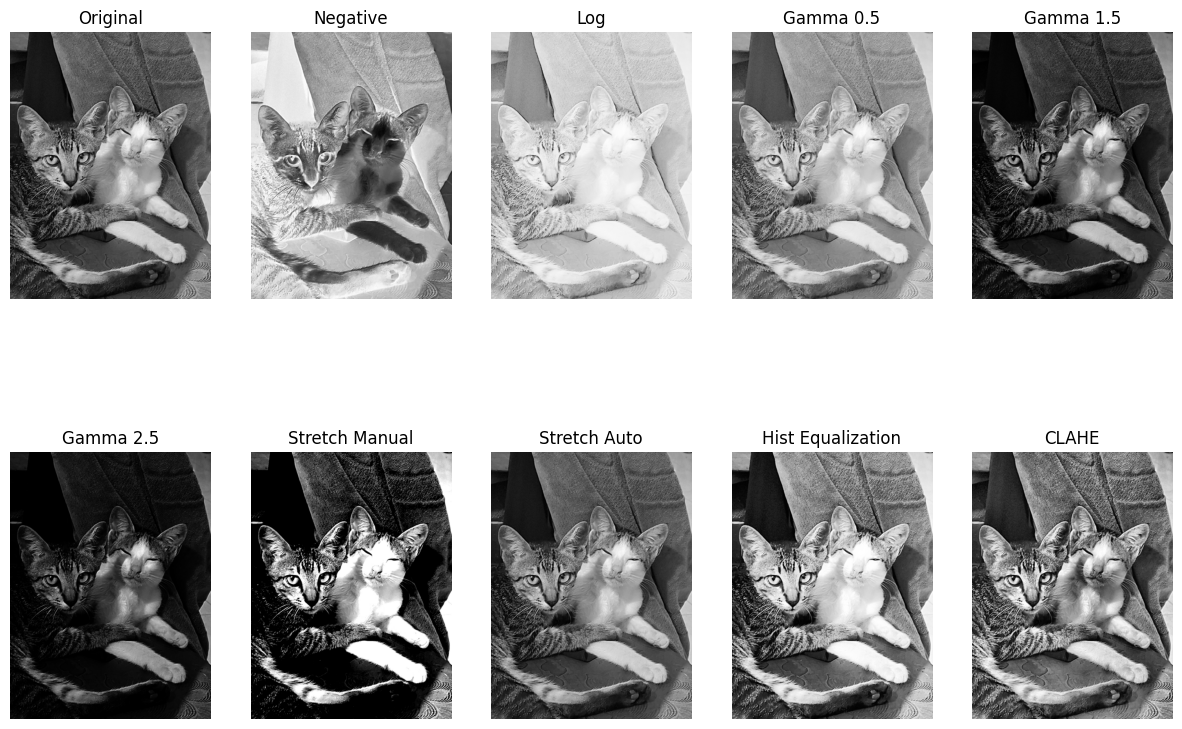

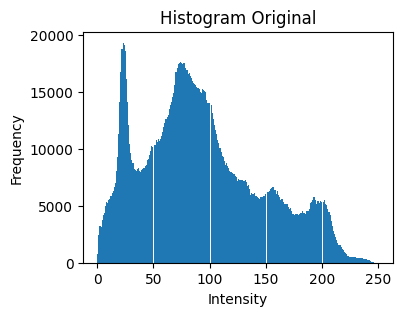

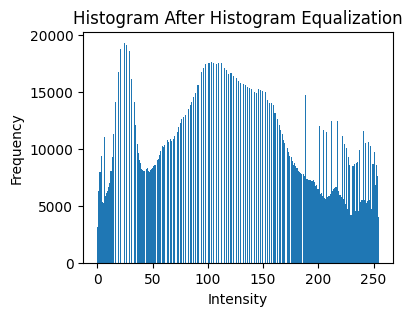

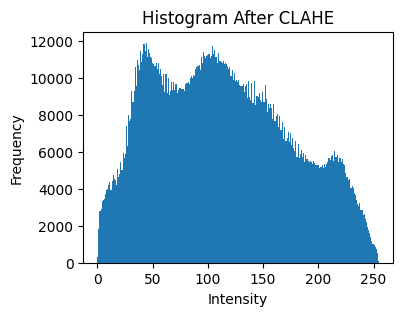


METRIC EVALUATION
Original
Contrast Ratio : 251
Entropy        : 7.62312057360291
SNR            : 1.7295782178821397

HistEq
Contrast Ratio : 255
Entropy        : 7.436972002467061
SNR            : 1.745004012834089

CLAHE
Contrast Ratio : 255
Entropy        : 7.867266420192977
SNR            : 1.8482991500399109

StretchAuto
Contrast Ratio : 255
Entropy        : 7.62312057360291
SNR            : 1.7217442277647623


Processing: Foto Model Warna Redup.jpeg


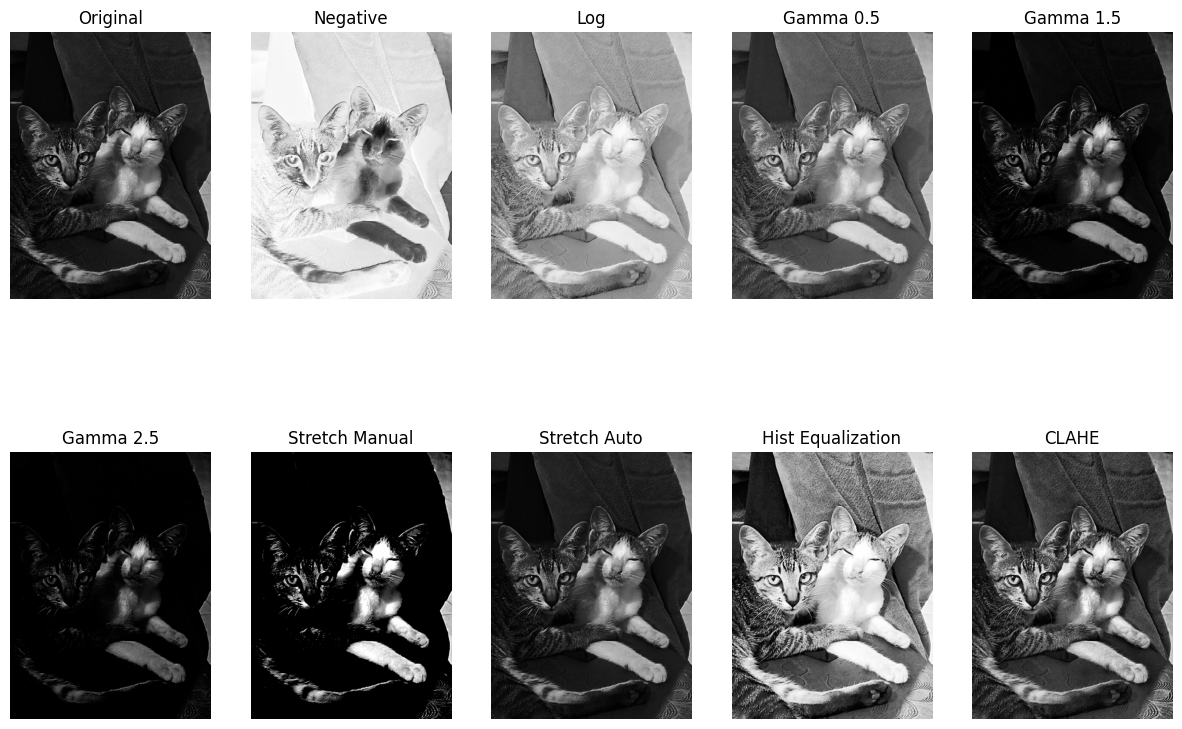

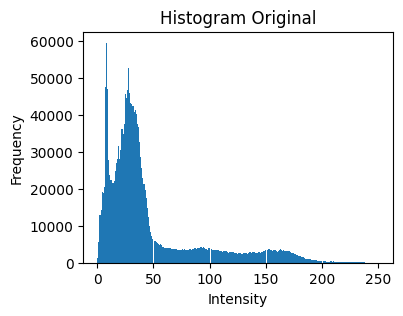

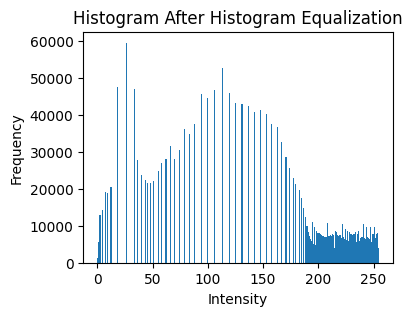

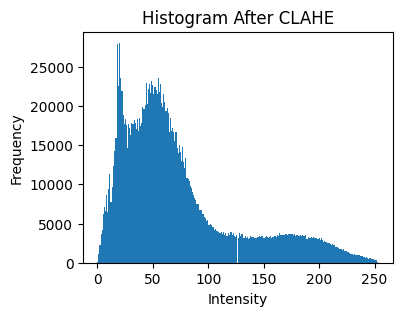


METRIC EVALUATION
Original
Contrast Ratio : 251
Entropy        : 6.710167970344808
SNR            : 1.0273373036553664

HistEq
Contrast Ratio : 255
Entropy        : 6.394498617391837
SNR            : 1.7699537342865361

CLAHE
Contrast Ratio : 254
Entropy        : 7.40570729878659
SNR            : 1.3491078661237195

StretchAuto
Contrast Ratio : 255
Entropy        : 6.710167970344808
SNR            : 1.0200493953394216


Processing: Foto Model Warna Terang.jpeg


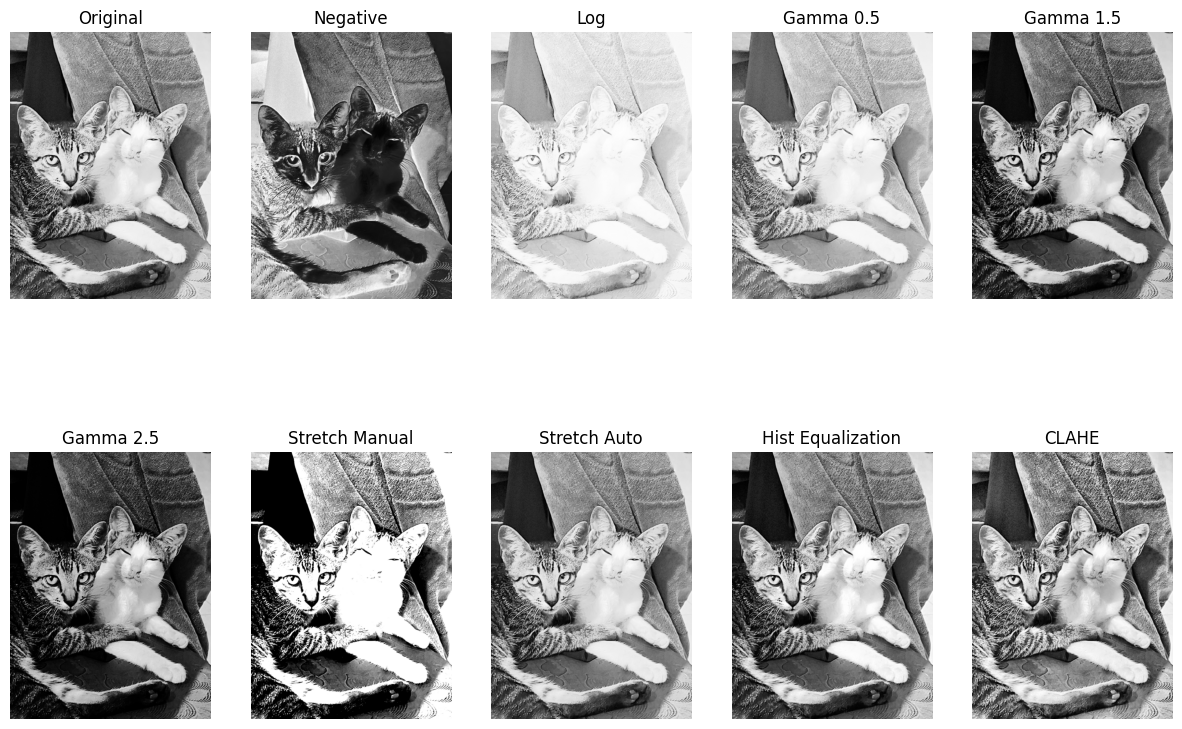

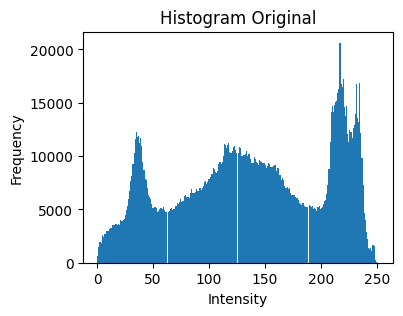

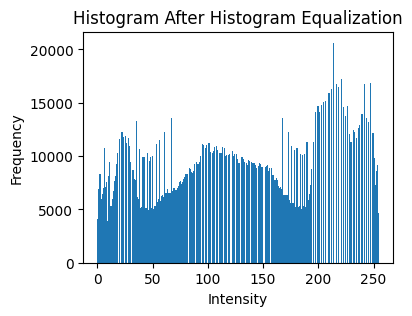

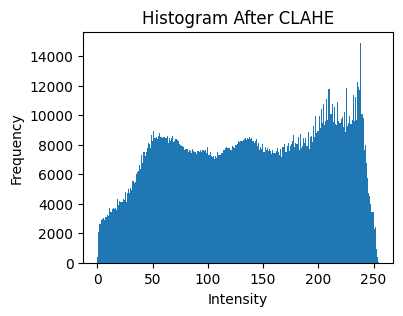


METRIC EVALUATION
Original
Contrast Ratio : 252
Entropy        : 7.808629381120129
SNR            : 2.0382160862486476

HistEq
Contrast Ratio : 255
Entropy        : 7.616872208213797
SNR            : 1.7362766888189642

CLAHE
Contrast Ratio : 255
Entropy        : 7.926066583584367
SNR            : 2.0047912885378403

StretchAuto
Contrast Ratio : 255
Entropy        : 7.808629381120129
SNR            : 2.0327892696178615



In [1]:
# ==========================================================
# PIPELINE ENHANCEMENT CITRA
# Optimalisasi Visual Underexposed & Overexposed Image
# ==========================================================

# ================================
# 1. INSTALL & IMPORT LIBRARY
# ================================

!pip -q install opencv-python matplotlib scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.measure import shannon_entropy

# ================================
# 2. UPLOAD 3 CITRA
# ================================

print("Upload 3 citra:")
print("1. Underexposed (gelap)")
print("2. Overexposed (terang)")
print("3. Iluminasi tidak merata")

uploaded = files.upload()

images = {}

for name in uploaded.keys():
    img = cv2.imread(name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    images[name] = gray

# ================================
# 3. POINT PROCESSING
# ================================

# Negative Transformation
def negative_transform(img):
    return 255 - img


# Log Transformation
def log_transform(img):

    c = 255 / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img)

    return np.array(log_img, dtype=np.uint8)


# Gamma Correction
def gamma_transform(img, gamma):

    img_norm = img / 255.0
    gamma_img = np.power(img_norm, gamma)

    return np.uint8(gamma_img * 255)


# ================================
# 4. HISTOGRAM BASED ENHANCEMENT
# ================================

# Contrast Stretching Manual
def contrast_stretch_manual(img, r1=70, r2=180):

    s1 = 0
    s2 = 255

    stretched = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            r = img[i,j]

            if r < r1:
                stretched[i,j] = s1/r1 * r

            elif r < r2:
                stretched[i,j] = ((s2-s1)/(r2-r1))*(r-r1)+s1

            else:
                stretched[i,j] = ((255-s2)/(255-r2))*(r-r2)+s2

    return stretched


# Contrast Stretching Automatic
def contrast_stretch_auto(img):

    rmin = np.min(img)
    rmax = np.max(img)

    stretched = (img - rmin) * (255/(rmax-rmin))

    return np.uint8(stretched)


# Histogram Equalization
def hist_equalization(img):

    return cv2.equalizeHist(img)


# CLAHE (Adaptive Histogram Equalization)
def clahe_enhancement(img):

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    return clahe.apply(img)

# ================================
# 5. METRIK EVALUASI
# ================================

def contrast_ratio(img):

    return np.max(img) - np.min(img)


def entropy_metric(img):

    return shannon_entropy(img)


def snr_metric(img):

    mean = np.mean(img)
    std = np.std(img)

    return mean / std if std != 0 else 0

# ================================
# 6. HISTOGRAM VISUALIZATION
# ================================

def show_histogram(img, title):

    plt.figure(figsize=(4,3))
    plt.hist(img.ravel(), bins=256)
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.show()

# ================================
# 7. PIPELINE PROCESSING
# ================================

for name, img in images.items():

    print("\n=================================")
    print("Processing:", name)
    print("=================================")

    # Point Processing
    negative = negative_transform(img)
    log_img = log_transform(img)

    gamma1 = gamma_transform(img, 0.5)
    gamma2 = gamma_transform(img, 1.5)
    gamma3 = gamma_transform(img, 2.5)

    # Histogram Methods
    stretch_manual = contrast_stretch_manual(img)
    stretch_auto = contrast_stretch_auto(img)

    hist_eq = hist_equalization(img)
    clahe = clahe_enhancement(img)

    # =============================
    # VISUALIZATION
    # =============================

    titles = [
        "Original",
        "Negative",
        "Log",
        "Gamma 0.5",
        "Gamma 1.5",
        "Gamma 2.5",
        "Stretch Manual",
        "Stretch Auto",
        "Hist Equalization",
        "CLAHE"
    ]

    images_list = [
        img,
        negative,
        log_img,
        gamma1,
        gamma2,
        gamma3,
        stretch_manual,
        stretch_auto,
        hist_eq,
        clahe
    ]

    plt.figure(figsize=(15,10))

    for i in range(len(images_list)):
        plt.subplot(2,5,i+1)
        plt.imshow(images_list[i], cmap='gray')
        plt.title(titles[i])
        plt.axis("off")

    plt.show()

    # =============================
    # HISTOGRAM BEFORE-AFTER
    # =============================

    show_histogram(img, "Histogram Original")
    show_histogram(hist_eq, "Histogram After Histogram Equalization")
    show_histogram(clahe, "Histogram After CLAHE")

    # =============================
    # METRIC EVALUATION
    # =============================

    methods = {
        "Original": img,
        "HistEq": hist_eq,
        "CLAHE": clahe,
        "StretchAuto": stretch_auto
    }

    print("\nMETRIC EVALUATION")

    for key, value in methods.items():

        cr = contrast_ratio(value)
        ent = entropy_metric(value)
        snr = snr_metric(value)

        print(f"{key}")
        print("Contrast Ratio :", cr)
        print("Entropy        :", ent)
        print("SNR            :", snr)
        print()